In [1]:
!pip install tensorflow keras matplotlib numpy scikit-learn seaborn

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("All libraries loaded ✅")

TensorFlow version: 2.20.0
All libraries loaded ✅


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples: (60000, 28, 28)
Test samples    : (10000, 28, 28)
Labels range    : 0 to 9


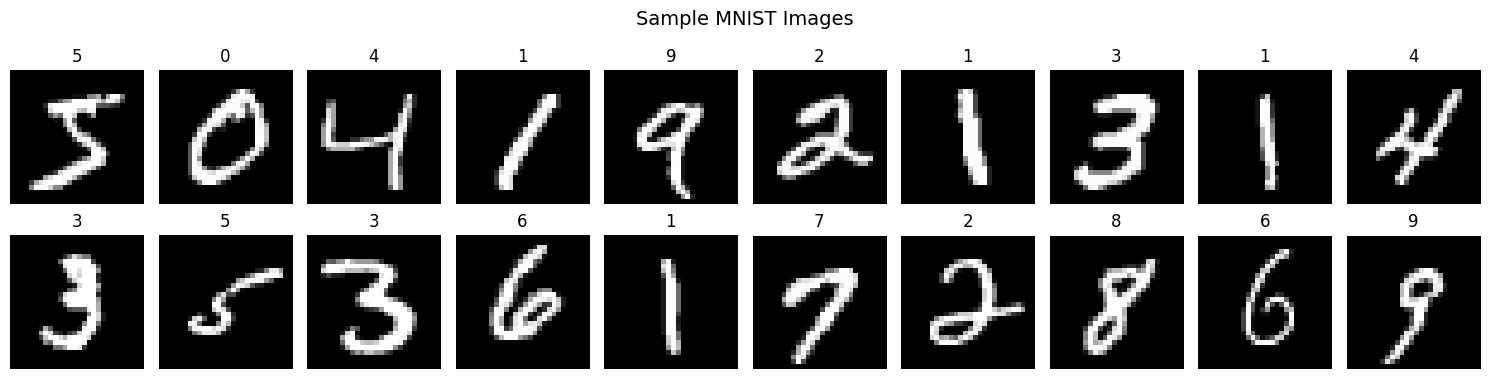

In [3]:
# Cell 3: Load MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training samples:", X_train.shape)
print("Test samples    :", X_test.shape)
print("Labels range    :", y_train.min(), "to", y_train.max())

# Visualize sample images
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(str(y_train[i]))
    ax.axis('off')
plt.suptitle("Sample MNIST Images", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
# Cell 4: Normalize and reshape
# Normalize pixel values 0-255 → 0.0-1.0
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32")  / 255.0

# Reshape: add channel dimension (28x28 → 28x28x1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test,  num_classes)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_cat.shape)
print("Preprocessing done ✅")

X_train shape: (60000, 28, 28, 1)
y_train shape: (60000, 10)
Preprocessing done ✅


In [5]:
# Cell 5: Build CNN Architecture
def build_cnn_model(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([
        # --- Block 1 ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # --- Block 2 ---
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # --- Block 3 ---
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # --- Classifier Head ---
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,749,226 (6.67 MB)

 Trainable params: 1,748,266 (6.67 MB)

 Non-trainable params: 960 (3.75 KB)

In [6]:
# Cell 6: Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(X_train)
print("Augmentation ready ✅")

Augmentation ready ✅


In [10]:
# Cell 8: Train
EPOCHS = 20
BATCH_SIZE = 128

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)
]

history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    epochs=EPOCHS,
    validation_data=(X_test, y_test_cat),
    callbacks=callbacks,
    verbose=1
)
print("Training complete ✅")

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.9009 - loss: 0.3257 - val_accuracy: 0.7194 - val_loss: 0.9663 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.9696 - loss: 0.0999 - val_accuracy: 0.9913 - val_loss: 0.0256 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.9768 - loss: 0.0756 - val_accuracy: 0.9894 - val_loss: 0.0301 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9809 - loss: 0.0626 - val_accuracy: 0.9894 - val_loss: 0.0292 - learning_rate: 0.0010
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9827 - loss: 0.0557 - val_accuracy: 0.9899 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.9871 - loss: 0.0414 - val_accuracy: 0.9944 - val_loss: 0.0146 - learning_rate: 2.0000e-04
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 23s 48ms/step - accuracy: 0.9884

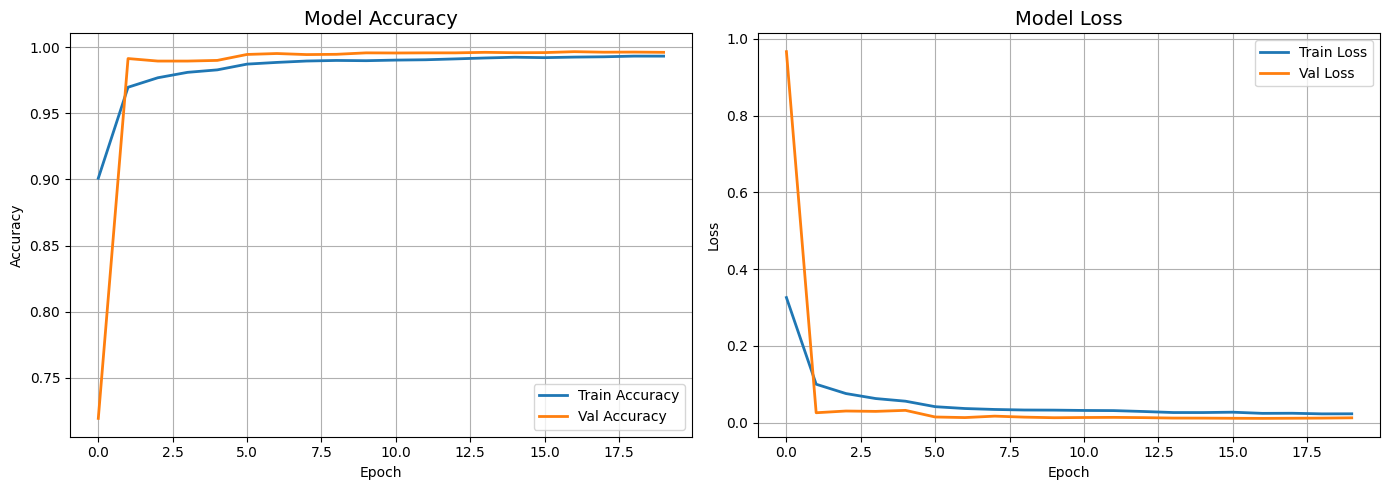

In [11]:
# Cell 9: Accuracy & Loss plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(True)

# Loss
ax2.plot(history.history['loss'],     label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

In [12]:
# Cell 10: Evaluate on test data
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 99.65%
Test Loss     : 0.0109


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step


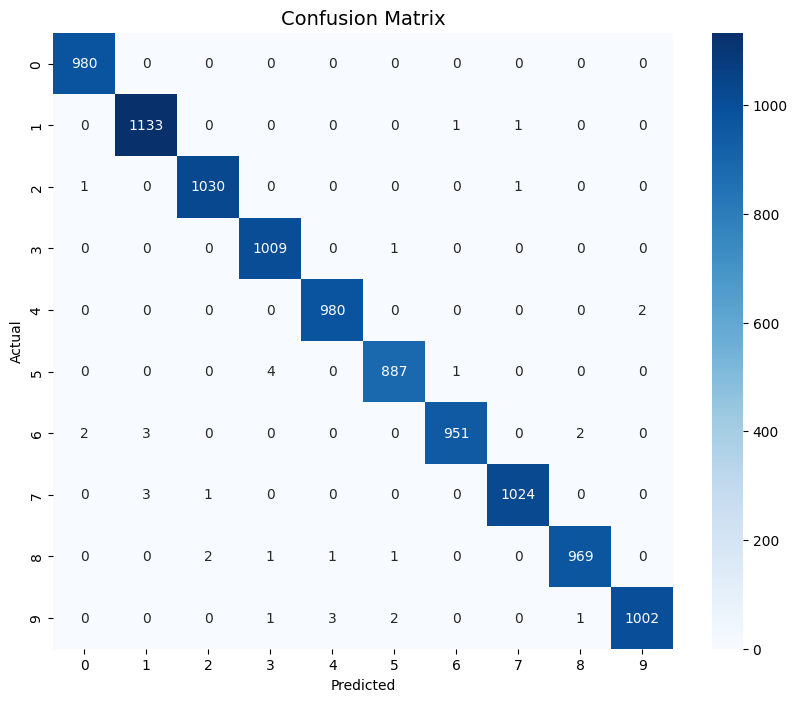


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      1.00      1.00      1032
           3       0.99      1.00      1.00      1010
           4       1.00      1.00      1.00       982
           5       1.00      0.99      0.99       892
           6       1.00      0.99      1.00       958
           7       1.00      1.00      1.00      1028
           8       1.00      0.99      1.00       974
           9       1.00      0.99      1.00      1009

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [13]:
# Cell 11: Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

In [14]:
# Cell 12: Load EMNIST Letters dataset
import tensorflow_datasets as tfds

# Load EMNIST Letters
ds_train, ds_test = tfds.load(
    'emnist/letters',
    split=['train', 'test'],
    as_supervised=True
)

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.transpose(image, perm=[1, 0, 2])   # fix EMNIST rotation
    label = label - 1                              # labels start at 1, shift to 0
    return image, label

BATCH = 128
ds_train = ds_train.map(preprocess).shuffle(10000).batch(BATCH).prefetch(1)
ds_test  = ds_test.map(preprocess).batch(BATCH).prefetch(1)

print("EMNIST dataset loaded ✅")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.OCCZLW_3.1.0/emnist-train.tfrecord-[0-9][0-9][0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/emnist/letters/incomplete.OCCZLW_3.1.0/emnist-test.tfrecord-[0-9][0-9][0-9…

Dataset emnist downloaded and prepared to /root/tensorflow_datasets/emnist/letters/3.1.0. Subsequent calls will reuse this data.
EMNIST dataset loaded ✅


In [15]:
# Cell 13: Build & Train EMNIST Model (A-Z = 26 classes)
emnist_model = build_cnn_model(input_shape=(28, 28, 1), num_classes=26)

emnist_model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_em = emnist_model.fit(
    ds_train,
    epochs=15,
    validation_data=ds_test,
    callbacks=callbacks,
    verbose=1
)
print("EMNIST training complete ✅")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
694/694 ━━━━━━━━━━━━━━━━━━━━ 36s 29ms/step - accuracy: 0.8134 - loss: 0.6151 - val_accuracy: 0.9118 - val_loss: 0.2633 - learning_rate: 0.0010
Epoch 2/15
694/694 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9087 - loss: 0.2758 - val_accuracy: 0.9159 - val_loss: 0.2412 - learning_rate: 0.0010
Epoch 3/15
694/694 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9235 - loss: 0.2298 - val_accuracy: 0.9293 - val_loss: 0.2067 - learning_rate: 0.0010
Epoch 4/15
694/694 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9369 - loss: 0.1824 - val_accuracy: 0.9371 - val_loss: 0.1780 - learning_rate: 2.0000e-04
Epoch 5/15
694/694 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9416 - loss: 0.1687 - val_accuracy: 0.9364 - val_loss: 0.1807 - learning_rate: 2.0000e-04
EMNIST training complete ✅


Saving sample 2.jpeg to sample 2.jpeg
Saving sample 3.jpeg to sample 3.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


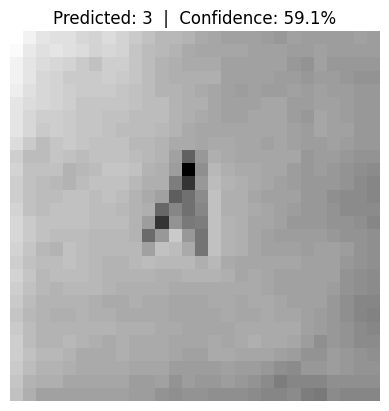

Predicted digit: 3 (59.1% confidence)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


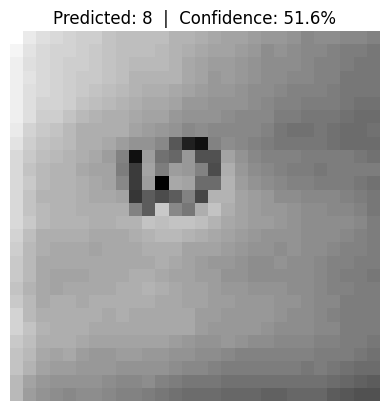

Predicted digit: 8 (51.6% confidence)


In [19]:
# Cell 14: Test with your own handwritten image
from google.colab import files
from PIL import Image

# Upload your handwritten image
uploaded = files.upload()

for fname in uploaded.keys():
    img = Image.open(fname).convert('L')          # grayscale
    img = img.resize((28, 28))
    img_arr = np.array(img).astype('float32') / 255.0
    img_arr = img_arr.reshape(1, 28, 28, 1)

    # Predict using MNIST model
    pred = np.argmax(model.predict(img_arr))
    confidence = np.max(model.predict(img_arr)) * 100

    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted: {pred}  |  Confidence: {confidence:.1f}%")
    plt.axis('off')
    plt.show()
    print(f"Predicted digit: {pred} ({confidence:.1f}% confidence)")

In [20]:
# Cell 15: Save model
model.save('mnist_cnn_model.h5')
emnist_model.save('emnist_cnn_model.h5')
print("Models saved ✅")

# Download to local machine
from google.colab import files
files.download('mnist_cnn_model.h5')

Models saved ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>